# Almost Periodic Function Experiments

本笔记本保留了原始的定性结构：首先改变近周期信号的噪声水平，然后将纯振荡序列与趋势加振荡序列进行比较。
在兼容 Qwen 的主分支下，LLM 路径使用共享的 validation_metric 自动调优默认值，而非传统的逐token NLL。


In [1]:
import os
import math
from collections import defaultdict

os.environ['OMP_NUM_THREADS'] = '4'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

from configs.runtime import describe_runtime
from data.serialize import SerializerSettings, deserialize_str
from experiments.model_defaults import (
    DEFAULT_LLMTIME_HYPERS,
    DEFAULT_PROMPTCAST_HYPERS,
    DEFAULT_REMOTE_MODEL,
    describe_model_capabilities,
)
from models.darts import get_arima_predictions_data
from models.llmtime import get_llmtime_predictions_data
from models.promptcast import get_promptcast_predictions_data
from models.utils import grid_iter
from models.validation_likelihood_tuning import get_autotuned_predictions_data

import warnings

warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

describe_runtime()
describe_model_capabilities(DEFAULT_REMOTE_MODEL)


D:\anaconda_py_package\Anaconda_envs\envs\llmtime\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'model': 'qwen-plus',
 'supports_sampling': True,
 'supports_nll_scoring': False,
 'supported_autotune_modes': ['validation_metric', 'disabled'],
 'default_autotune_mode': 'validation_metric'}

In [2]:
RANDOM_SEED = 11
NUM_POINTS = 500
TEST_FRAC = 0.2
REMOTE_NUM_SAMPLES = 10
NOTEBOOK_PARALLEL = False
INCLUDE_PROMPTCAST = False

np.random.seed(RANDOM_SEED)

def build_model_registry(include_promptcast=INCLUDE_PROMPTCAST):
    qwen_hypers = dict(DEFAULT_LLMTIME_HYPERS)
    promptcast_hypers = dict(DEFAULT_PROMPTCAST_HYPERS)
    arima_hypers = dict(p=[12, 20, 30], d=[1, 2], q=[0, 1, 2])

    model_hypers = {
        'LLMTime Qwen': qwen_hypers,
        'ARIMA': arima_hypers,
    }
    model_predict_fns = {
        'LLMTime Qwen': get_llmtime_predictions_data,
        'ARIMA': get_arima_predictions_data,
    }
    model_names = ['LLMTime Qwen', 'ARIMA']

    if include_promptcast:
        model_hypers['PromptCast Qwen'] = promptcast_hypers
        model_predict_fns['PromptCast Qwen'] = get_promptcast_predictions_data
        model_names.insert(1, 'PromptCast Qwen')

    return model_hypers, model_predict_fns, model_names

model_hypers, model_predict_fns, model_names = build_model_registry()
pd.DataFrame(
    [
        {
            'model_name': model_name,
            'autotune_mode': model_hypers[model_name].get('autotune_mode', 'nll'),
            'num_samples': REMOTE_NUM_SAMPLES,
        }
        for model_name in model_names
    ]
)


,model_name,autotune_mode,num_samples
0,LLMTime Qwen,validation_metric,10
1,ARIMA,nll,10


In [3]:
def split_series(series, testfrac=TEST_FRAC):
    splitpoint = int(len(series) * (1 - testfrac))
    train = series.iloc[:splitpoint]
    test = series.iloc[splitpoint:]
    return train, test


def align_prediction_and_truth(test, pred_dict, model_name):
    pred = pred_dict.get('median')
    if pred is None:
        raise ValueError(f'{model_name} did not return a median forecast.')
    pred = np.asarray(pred, dtype=float).reshape(-1)
    truth = np.asarray(test.values, dtype=float).reshape(-1)

    raw_pred_len = len(pred)
    raw_truth_len = len(truth)
    if raw_pred_len != raw_truth_len:
        print(
            f'{model_name}: forecast length mismatch raw_pred_len={raw_pred_len}, '
            f'truth_len={raw_truth_len}; truncating to common prefix.'
        )
    common_len = min(raw_pred_len, raw_truth_len)
    pred = pred[:common_len]
    truth = truth[:common_len]
    index = test.index[:common_len]

    finite_mask = np.isfinite(pred) & np.isfinite(truth)
    if finite_mask.sum() != common_len:
        print(
            f'{model_name}: dropping {common_len - finite_mask.sum()} positions because '
            f'prediction/truth contains NaN or inf.'
        )
    pred = pred[finite_mask]
    truth = truth[finite_mask]
    index = index[finite_mask]

    pred_series = pd.Series(pred, index=index, name=f'{model_name}_pred')
    truth_series = pd.Series(truth, index=index, name='truth')
    alignment = {
        'raw_prediction_len': raw_pred_len,
        'raw_truth_len': raw_truth_len,
        'aligned_len': len(pred_series),
        'short_prediction_or_padding': raw_pred_len < raw_truth_len,
    }
    return pred_series, truth_series, alignment


def compute_metrics(truth_series, pred_series):
    return {
        'MSE': float(mean_squared_error(truth_series.values, pred_series.values)),
        'MAE': float(mean_absolute_error(truth_series.values, pred_series.values)),
    }


def get_settings_from_pred_dict(pred_dict):
    settings = pred_dict.get('best_hyper', {}).get('settings')
    if settings is None:
        settings = DEFAULT_LLMTIME_HYPERS['settings']
    if isinstance(settings, dict):
        settings = SerializerSettings(**settings)
    return settings


def summarize_generation(pred_dict, horizon, model_name):
    samples = pred_dict.get('samples')
    sample_count = None
    if isinstance(samples, pd.DataFrame):
        sample_count = len(samples)
    elif isinstance(samples, list) and samples and isinstance(samples[0], pd.DataFrame):
        sample_count = len(samples[0])

    completions_list = pred_dict.get('completions_list')
    if completions_list and isinstance(completions_list[0], list):
        completions = completions_list[0]
    else:
        completions = completions_list or []

    short_count = None
    example_completion = None
    if completions:
        settings = get_settings_from_pred_dict(pred_dict)
        parsed_lengths = []
        for completion in completions:
            parsed = deserialize_str(completion, settings, ignore_last=False, steps=horizon)
            parsed_lengths.append(0 if parsed is None else len(parsed))
        short_count = int(sum(length < horizon for length in parsed_lengths))
        example_completion = completions[0][:200]
    else:
        example_completion = 'N/A (non-LLM baseline or no raw completion text)'

    return {
        'model': model_name,
        'forecast_horizon': int(horizon),
        'num_samples': sample_count,
        'short_prediction_or_padding': bool(short_count and short_count > 0),
        'short_completion_count': short_count,
        'example_completion': example_completion,
    }


def plot_preds(train, test, pred_series, model_name, metrics, show_samples=False, pred_dict=None):
    plt.figure(figsize=(8, 6), dpi=100)
    plt.title(model_name)
    plt.plot(train.index, train.values, label='Train')
    plt.plot(test.index, test.values, label='Truth', color='black')
    plt.plot(pred_series.index, pred_series.values, label=model_name, color='purple')
    if show_samples and pred_dict is not None and pred_dict.get('samples') is not None:
        samples = pred_dict['samples']
        if isinstance(samples, pd.DataFrame):
            sample_values = samples.values
            sample_index = samples.columns
            for i in range(min(10, sample_values.shape[0])):
                plt.plot(sample_index, sample_values[i], color='purple', alpha=0.2, linewidth=1)
    plt.legend(loc='upper left')
    metrics_text = f"MSE: {metrics['MSE']:.4f}\nMAE: {metrics['MAE']:.4f}"
    plt.text(
        0.03,
        0.82,
        metrics_text,
        transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.6),
    )
    plt.show()


def run_model(train, test, ds_name, model_name, show_samples=False):
    hyper_grid = dict(model_hypers[model_name])
    if model_name.startswith('PromptCast'):
        hyper_grid['dataset_name'] = ds_name
    if model_name != 'ARIMA':
        horizon_budget = max(512, len(test) * 32)
        hyper_grid['max_new_tokens'] = max(int(hyper_grid.get('max_new_tokens', 0) or 0), horizon_budget)
        hyper_grid['max_retries_on_short'] = max(int(hyper_grid.get('max_retries_on_short', 0) or 0), 3)
    hypers = list(grid_iter(hyper_grid))
    num_samples = REMOTE_NUM_SAMPLES if model_name != 'ARIMA' else 100
    pred_dict = get_autotuned_predictions_data(
        train,
        test,
        hypers,
        num_samples,
        model_predict_fns[model_name],
        verbose=False,
        parallel=NOTEBOOK_PARALLEL,
    )
    pred_series, truth_series, alignment = align_prediction_and_truth(test, pred_dict, model_name)
    metrics = compute_metrics(truth_series, pred_series)
    plot_preds(train, test, pred_series, model_name, metrics, show_samples=show_samples, pred_dict=pred_dict)
    summary = summarize_generation(pred_dict, len(test), model_name)
    summary['autotune_mode'] = pred_dict.get('autotune', {}).get('mode', 'fixed')
    summary['aligned_points'] = alignment['aligned_len']
    return {
        'pred_dict': pred_dict,
        'pred_series': pred_series,
        'truth_series': truth_series,
        'alignment': alignment,
        'metrics': metrics,
        'summary': summary,
    }


def out(train, test, ds_name, show_samples=False):
    outputs = {}
    metric_rows = []
    summary_rows = []
    for model_name in model_names:
        print(f'Running {ds_name} | {model_name}')
        model_output = run_model(train, test, ds_name, model_name, show_samples=show_samples)
        outputs[model_name] = model_output
        metric_rows.append({'model': model_name, **model_output['metrics']})
        summary_rows.append(model_output['summary'])
    outputs['metrics'] = pd.DataFrame(metric_rows).set_index('model').sort_values('MSE')
    outputs['summary'] = pd.DataFrame(summary_rows).set_index('model')
    return outputs


def diff_sigmas(sigma, num_points=NUM_POINTS, show_samples=False):
    x = np.linspace(0, 8 * math.pi, num_points)
    clean_signal = np.cos(2 * x) + np.cos(2 * math.pi * x)
    rng = np.random.default_rng(RANDOM_SEED + int(round(sigma * 1000)))
    noise = rng.normal(0.0, sigma, len(x))
    observed = np.round(clean_signal + noise, 2)
    series = pd.Series(observed, index=pd.RangeIndex(len(observed)), name=f'sigma={sigma}')
    train, test = split_series(series)

    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(x[:len(train)], train.values, label='Train')
    plt.plot(x[len(train):], test.values, label='Test')
    plt.title(f'cos(2x) + cos(2?x) with noise sigma={sigma}')
    plt.legend()
    plt.show()

    result = out(train, test, f'cosines_sigma_{sigma}', show_samples=show_samples)
    result['x'] = x
    result['train'] = train
    result['test'] = test
    return result


def compare_out(train1, test1, ds_name1, train2, test2, ds_name2, show_samples=False):
    outputs = {}
    metric_rows = []
    summary_rows = []
    for model_name in model_names:
        print(f'Running paired comparison | {model_name}')
        first_output = run_model(train1, test1, ds_name1, model_name, show_samples=show_samples)
        second_output = run_model(train2, test2, ds_name2, model_name, show_samples=show_samples)
        outputs[(ds_name1, model_name)] = first_output
        outputs[(ds_name2, model_name)] = second_output

        metric_rows.append({'dataset': ds_name1, 'model': model_name, **first_output['metrics']})
        metric_rows.append({'dataset': ds_name2, 'model': model_name, **second_output['metrics']})
        summary_rows.append({'dataset': ds_name1, **first_output['summary']})
        summary_rows.append({'dataset': ds_name2, **second_output['summary']})

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), dpi=100)
        ax1.set_title(f'{model_name} | {ds_name1}')
        ax1.plot(train1.index, train1.values, label='Train')
        ax1.plot(test1.index, test1.values, label='Truth', color='black')
        ax1.plot(first_output['pred_series'].index, first_output['pred_series'].values, label=model_name, color='purple')
        ax1.legend(loc='upper left')
        ax1.text(0.03, 0.75, f"MSE: {first_output['metrics']['MSE']:.4f}\nMAE: {first_output['metrics']['MAE']:.4f}", transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.6))

        ax2.set_title(f'{model_name} | {ds_name2}')
        ax2.plot(train2.index, train2.values, label='Train')
        ax2.plot(test2.index, test2.values, label='Truth', color='black')
        ax2.plot(second_output['pred_series'].index, second_output['pred_series'].values, label=model_name, color='purple')
        ax2.legend(loc='upper left')
        ax2.text(0.03, 0.75, f"MSE: {second_output['metrics']['MSE']:.4f}\nMAE: {second_output['metrics']['MAE']:.4f}", transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.6))
        plt.tight_layout()
        plt.show()

    outputs['metrics'] = pd.DataFrame(metric_rows).set_index(['dataset', 'model']).sort_values(['dataset', 'MSE'])
    outputs['summary'] = pd.DataFrame(summary_rows).set_index(['dataset', 'model'])
    return outputs


def build_trend_comparison(noise_sigma, num_points=NUM_POINTS):
    x = np.linspace(0, 16 * math.pi, num_points)
    rng = np.random.default_rng(RANDOM_SEED + 1000 + int(round(noise_sigma * 1000)))
    noise = rng.normal(0.0, noise_sigma, num_points)
    periodic = np.sin(x) + noise
    trend_periodic = 0.2 * x + periodic

    series1 = pd.Series(periodic, index=pd.RangeIndex(num_points), name='sin(x)')
    series2 = pd.Series(trend_periodic, index=pd.RangeIndex(num_points), name='x_plus_sin(x)')
    train1, test1 = split_series(series1)
    train2, test2 = split_series(series2)

    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(x, trend_periodic, label='0.2*x + sin(x) + noise')
    plt.plot(x, periodic, label='sin(x) + noise')
    plt.title(f'Trend vs oscillation comparison | sigma={noise_sigma}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

    return train1, test1, train2, test2


In [4]:
sigma_results = {}
pair_results = {}


# cos(2*pi*t) + cos(2*t) + noise (sigma=0)


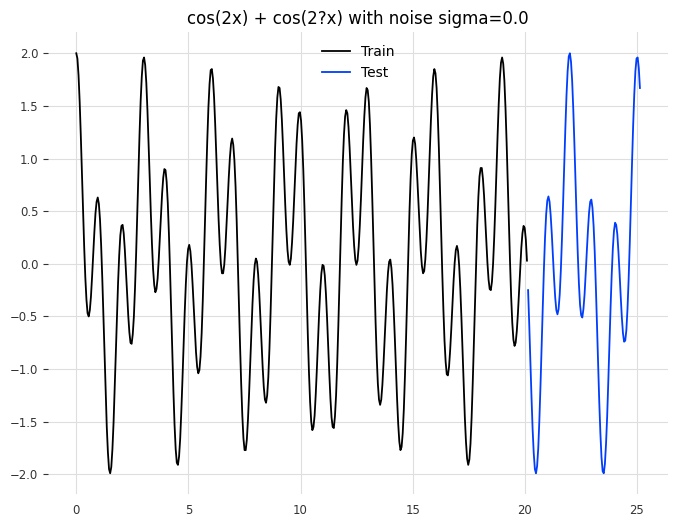

Running cosines_sigma_0.0 | LLMTime Qwen


100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [11:34<00:00, 694.08s/it]


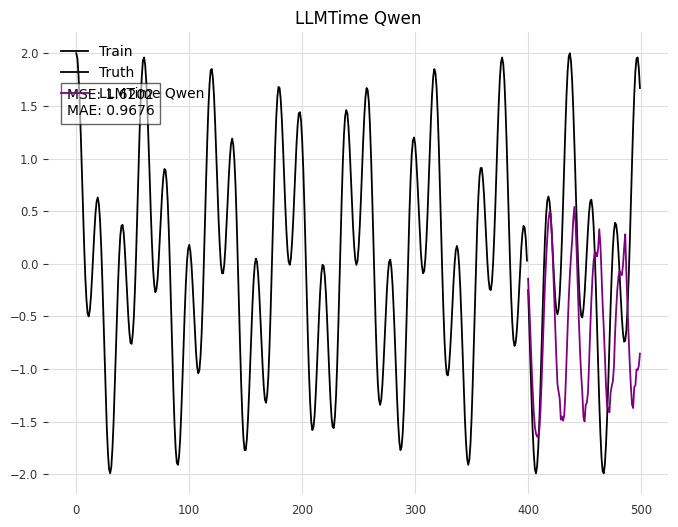

Running cosines_sigma_0.0 | ARIMA


Hyperparameter search: 100%|███████████████████████████████████████████████████████████| 18/18 [01:41<00:00,  5.65s/it]


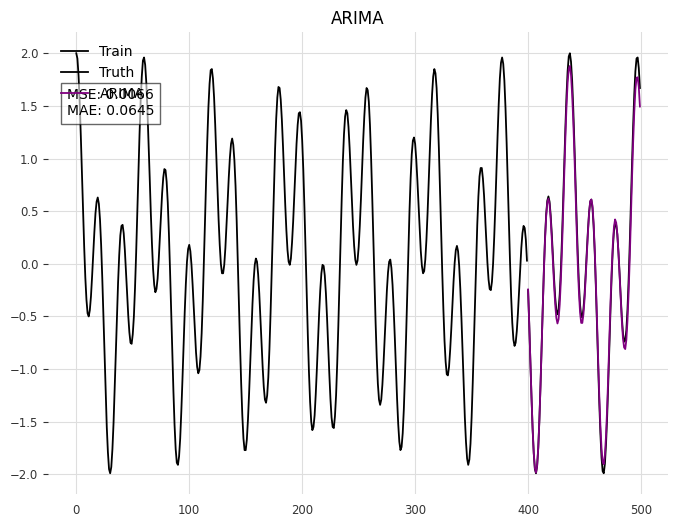

In [5]:
sigma = 0.0
sigma_results[f'sigma={sigma}'] = diff_sigmas(sigma)


In [7]:
display(sigma_results['sigma=0.0']['summary'])
display(sigma_results['sigma=0.0']['metrics'])


,forecast_horizon,num_samples,short_prediction_or_padding,short_completion_count,example_completion,autotune_mode,aligned_points
model,,,,,,,
LLMTime Qwen,100,10,False,0.0,"6 3 4 , 5 6 1 , 4 8 7 , 4 2 0 , 3 6 6 , 3 3 0 ...",validation_metric,100
ARIMA,100,100,False,NaN,N/A (non-LLM baseline or no raw completion text),nll,100


,MSE,MAE
model,,
ARIMA,0.006620,0.064522
LLMTime Qwen,1.620235,0.967553


# cos(2*pi*t) + cos(2*t) + noise (sigma=0.1)


In [ ]:
sigma = 0.1
sigma_results[f'sigma={sigma}'] = diff_sigmas(sigma)


In [ ]:
display(sigma_results['sigma=0.1']['summary'])
display(sigma_results['sigma=0.1']['metrics'])


# cos(2*pi*t) + cos(2*t) + noise (sigma=0.2)


In [ ]:
sigma = 0.2
sigma_results[f'sigma={sigma}'] = diff_sigmas(sigma)


In [ ]:
display(sigma_results['sigma=0.2']['summary'])
display(sigma_results['sigma=0.2']['metrics'])


# cos(2*pi*t) + cos(2*t) + noise (sigma=0.3)


In [ ]:
sigma = 0.3
sigma_results[f'sigma={sigma}'] = diff_sigmas(sigma)


In [ ]:
display(sigma_results['sigma=0.3']['summary'])
display(sigma_results['sigma=0.3']['metrics'])


# cos(2*pi*t) + cos(2*t) + noise (sigma=0.4)


In [ ]:
sigma = 0.4
sigma_results[f'sigma={sigma}'] = diff_sigmas(sigma)


In [ ]:
display(sigma_results['sigma=0.4']['summary'])
display(sigma_results['sigma=0.4']['metrics'])


## Noise-Level Summary


In [ ]:
sigma_metric_summary = pd.concat(
    [
        result['metrics'].assign(experiment=sigma_name)
        for sigma_name, result in sigma_results.items()
    ]
).reset_index().set_index(['experiment', 'model']).sort_values(['experiment', 'MSE'])
display(sigma_metric_summary)


In [ ]:
sigma_names = list(sigma_results.keys())
llmtime_mse = [sigma_results[name]['metrics'].loc['LLMTime Qwen', 'MSE'] for name in sigma_names]
arima_mse = [sigma_results[name]['metrics'].loc['ARIMA', 'MSE'] for name in sigma_names]

bar_width = 0.35
plt.figure(figsize=(8, 5), dpi=100)
plt.bar([i - bar_width / 2 for i in range(len(sigma_names))], llmtime_mse, width=bar_width, label='LLMTime Qwen MSE')
plt.bar([i + bar_width / 2 for i in range(len(sigma_names))], arima_mse, width=bar_width, label='ARIMA MSE')
plt.legend()
plt.title('MSE across noise levels')
plt.xlabel('Sigma')
plt.ylabel('MSE')
plt.xticks(range(len(sigma_names)), sigma_names)
plt.show()


# 0.2*x + sin(x) + noise (sigma=0)


In [ ]:
noise_sigma = 0.0
train1, test1, train2, test2 = build_trend_comparison(noise_sigma)
pair_results[f'sigma={noise_sigma}'] = compare_out(
    train1,
    test1,
    'sin(x)',
    train2,
    test2,
    '0.2*x + sin(x)',
    show_samples=False,
)


In [ ]:
display(pair_results['sigma=0']['summary'])
display(pair_results['sigma=0']['metrics'])


# 0.2*x + sin(x) + noise (sigma=0.05)


In [ ]:
noise_sigma = 0.05
train1, test1, train2, test2 = build_trend_comparison(noise_sigma)
pair_results[f'sigma={noise_sigma}'] = compare_out(
    train1,
    test1,
    'sin(x)',
    train2,
    test2,
    '0.2*x + sin(x)',
    show_samples=False,
)


In [ ]:
display(pair_results['sigma=0.05']['summary'])
display(pair_results['sigma=0.05']['metrics'])


# 0.2*x + sin(x) + noise (sigma=0.1)


In [ ]:
noise_sigma = 0.1
train1, test1, train2, test2 = build_trend_comparison(noise_sigma)
pair_results[f'sigma={noise_sigma}'] = compare_out(
    train1,
    test1,
    'sin(x)',
    train2,
    test2,
    '0.2*x + sin(x)',
    show_samples=False,
)


In [ ]:
display(pair_results['sigma=0.1']['summary'])
display(pair_results['sigma=0.1']['metrics'])


# 0.2*x + sin(x) + noise (sigma=0.2)


In [ ]:
noise_sigma = 0.2
train1, test1, train2, test2 = build_trend_comparison(noise_sigma)
pair_results[f'sigma={noise_sigma}'] = compare_out(
    train1,
    test1,
    'sin(x)',
    train2,
    test2,
    '0.2*x + sin(x)',
    show_samples=False,
)


In [ ]:
display(pair_results['sigma=0.2']['summary'])
display(pair_results['sigma=0.2']['metrics'])


## Trend-Comparison Summary

趋势对比摘要
配对部分主要仍为定性分析，但通过对齐的MSE/MAE表格和生成的摘要，可以更轻松地观察到Qwen原生预测何时表现得像一个纯振荡模型，以及趋势泄漏或短完井何时开始产生影响。


In [ ]:
pair_metric_summary = pd.concat(
    [
        result['metrics'].assign(experiment=sigma_name)
        for sigma_name, result in pair_results.items()
    ]
).reset_index().set_index(['experiment', 'dataset', 'model']).sort_values(['experiment', 'dataset', 'MSE'])
display(pair_metric_summary)
